In [1]:
from sklearn.datasets import load_iris
import pandas as pd

In [2]:
iris = load_iris(as_frame=True)
df = iris.frame
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [3]:
X= df.drop("target",axis=1)
X.shape

(150, 4)

In [4]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
from scipy.cluster.hierarchy import linkage

Z= linkage(X_scaled,
           method = "ward")

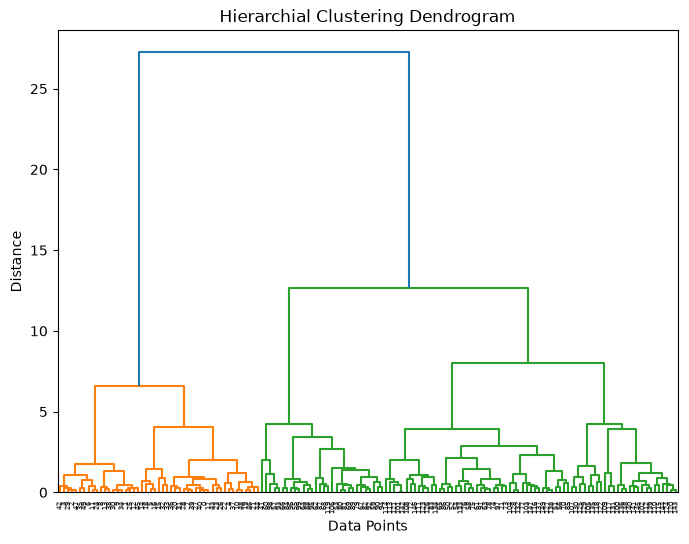

In [6]:
from scipy.cluster.hierarchy import dendrogram
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

dendrogram(Z)

plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.title("Hierarchial Clustering Dendrogram")

plt.show()

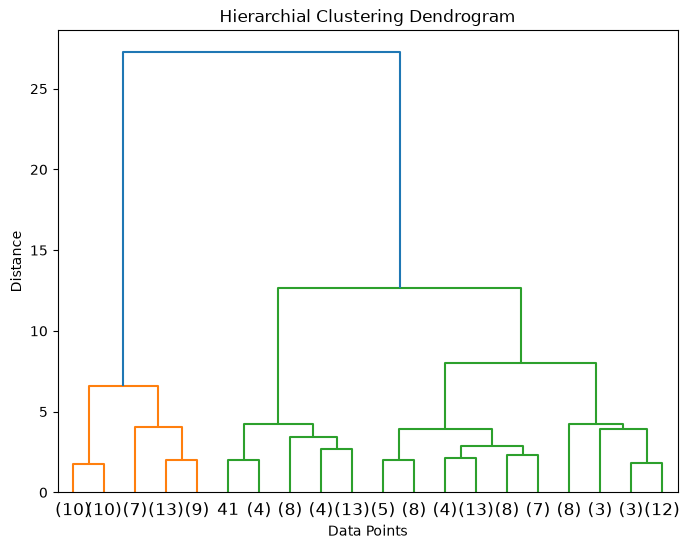

In [7]:
plt.figure(figsize=(8,6))

dendrogram(
    Z,
    truncate_mode="lastp",
    p=20
)

plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.title("Hierarchial Clustering Dendrogram")

plt.show()

In [8]:
# If we want to label the Dendrogram
from sklearn.cluster import AgglomerativeClustering

model = AgglomerativeClustering(
    n_clusters = 3,
    linkage = "ward"
)

labels = model.fit_predict(X_scaled)

In [9]:
labels

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 2, 0, 2, 0, 2, 0, 2, 2, 0, 2, 0, 2, 0,
       2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 0, 2, 0, 0, 2,
       2, 2, 2, 0, 2, 2, 2, 2, 2, 0, 2, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [10]:
df["Hierarchial_Cluster"] = labels

In [11]:
df["Hierarchial_Cluster"].value_counts().sort_index()

Hierarchial_Cluster
0    71
1    49
2    30
Name: count, dtype: int64

Different Linkage Methods

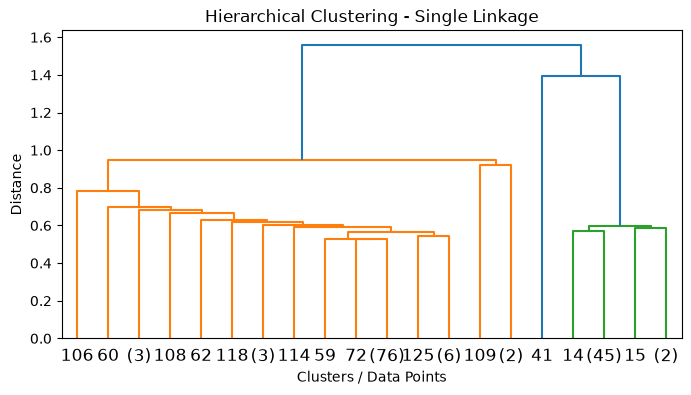

In [12]:
# Single Linkage (Calculated by Minimum Distance )
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

Z_single = linkage(
    X_scaled,
    method="single"
)

plt.figure(figsize=(8, 4))

dendrogram(
    Z_single,
    truncate_mode="lastp",
    p=20
)

plt.title("Hierarchical Clustering - Single Linkage")
plt.xlabel("Clusters / Data Points")
plt.ylabel("Distance")

plt.show()

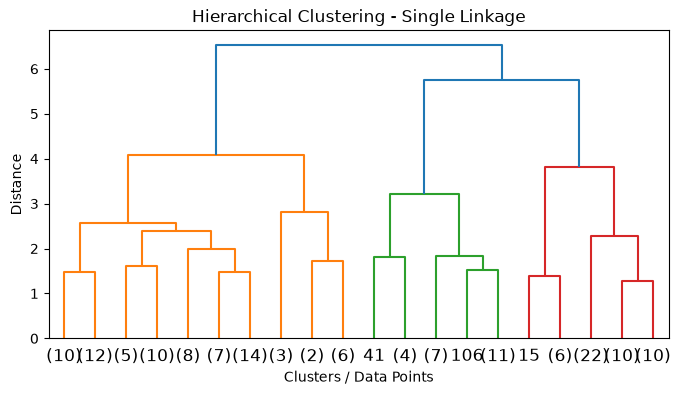

In [13]:
# Complete Linkage (Claculated by largest Distance )
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

Z_single = linkage(
    X_scaled,
    method="complete"
)

plt.figure(figsize=(8, 4))

dendrogram(
    Z_single,
    truncate_mode="lastp",
    p=20
)

plt.title("Hierarchical Clustering - Single Linkage")
plt.xlabel("Clusters / Data Points")
plt.ylabel("Distance")

plt.show()

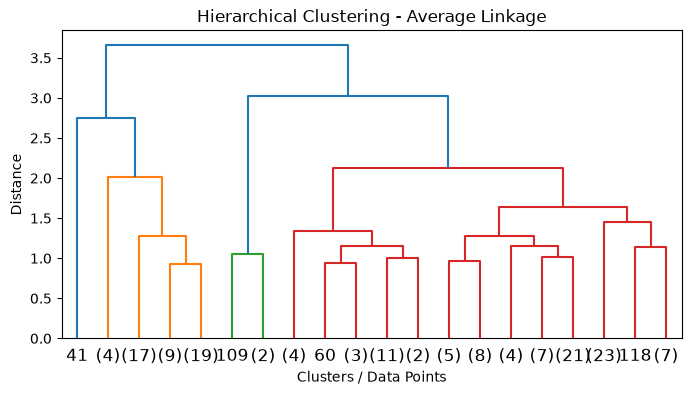

In [14]:
# Average Linkage calculates Average Distance
Z_average = linkage(
    X_scaled,
    method="average"
)

plt.figure(figsize=(8, 4))

dendrogram(
    Z_average,
    truncate_mode="lastp",
    p=20
)

plt.title("Hierarchical Clustering - Average Linkage")
plt.xlabel("Clusters / Data Points")
plt.ylabel("Distance")

plt.show()

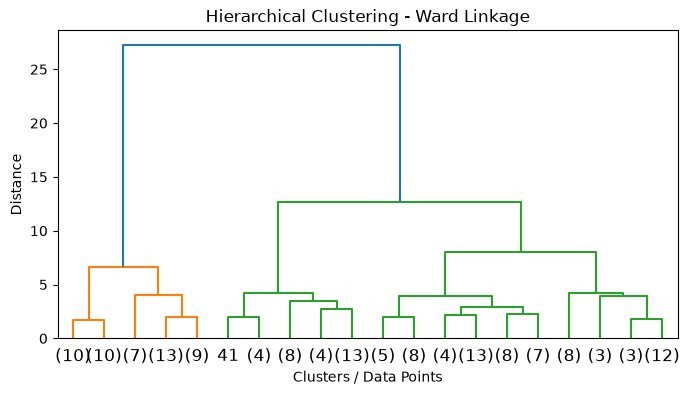

In [15]:
# ward Linkage (Merge clusters in a way that keeps the resulting clusters as compact as possible.)
Z_ward = linkage(
    X_scaled,
    method="ward"
)

plt.figure(figsize=(8, 4))

dendrogram(
    Z_ward,
    truncate_mode="lastp",
    p=20
)

plt.title("Hierarchical Clustering - Ward Linkage")
plt.xlabel("Clusters / Data Points")
plt.ylabel("Distance")

plt.show()

On Iris Dataset from start to finish

In [16]:
from sklearn.cluster import AgglomerativeClustering
model=AgglomerativeClustering(
    n_clusters = 3,
    linkage="ward"
)

In [17]:
labesl= model.fit_predict(X_scaled)
labels[:10]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [18]:
df["Hierarchial Clustering"] = labels
df["Hierarchial Clustering"].value_counts().sort_index()

Hierarchial Clustering
0    71
1    49
2    30
Name: count, dtype: int64

In [19]:
from sklearn.metrics import silhouette_score
score = silhouette_score(
    X_scaled,
    labels
)

print("Silhouette Score",score)

Silhouette Score 0.4466890410285909


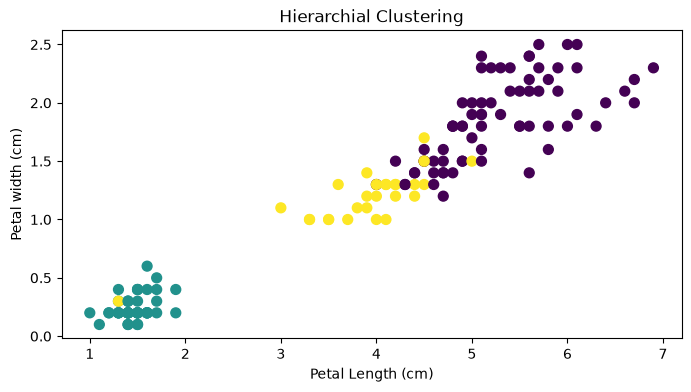

In [20]:
# Visualizing the Data
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.scatter(
    df["petal length (cm)"],
    df["petal width (cm)"],
    c=df["Hierarchial_Cluster"],
    s=50
)

plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal width (cm)")
plt.title("Hierarchial Clustering")

plt.show()

In [21]:
pd.crosstab(
    df["target"],
    df["Hierarchial_Cluster"]
)

Hierarchial_Cluster,0,1,2
target,,,
0,0,49,1
1,23,0,27
2,48,0,2


In [22]:
from sklearn.cluster import AgglomerativeClustering

model = AgglomerativeClustering(
    n_clusters=None,
    distance_threshold=5,
    linkage="ward"
)

labels = model.fit_predict(X_scaled)

In [23]:
print(pd.Series(labels).value_counts().sort_index())

0    30
1    26
2    29
3    45
4    20
Name: count, dtype: int64


In [24]:
Z_ward = linkage(
    X_scaled,
    method="ward"
)

Z_ward[-10:, 2]

array([ 3.44191215,  3.93266869,  3.95076988,  4.06134011,  4.22703313,
        4.24348495,  6.60781224,  8.00474726, 12.63684352, 27.24991146])

In [25]:
Z_ward[-15:, 2]

array([ 2.01781256,  2.14172453,  2.3033894 ,  2.69536867,  2.86888385,
        3.44191215,  3.93266869,  3.95076988,  4.06134011,  4.22703313,
        4.24348495,  6.60781224,  8.00474726, 12.63684352, 27.24991146])

In [26]:
from sklearn.cluster import AgglomerativeClustering

model = AgglomerativeClustering(
    n_clusters=None,
    distance_threshold=10,
    linkage="ward"
)

labels_threshold = model.fit_predict(X_scaled)

print("Number of clusters:", len(set(labels_threshold)))
print(
    pd.Series(labels_threshold)
    .value_counts()
    .sort_index()
)

Number of clusters: 3
0    71
1    49
2    30
Name: count, dtype: int64


In [27]:
model = AgglomerativeClustering(
    n_clusters=None,
    distance_threshold=5,
    linkage="ward"
)

labels_threshold = model.fit_predict(X_scaled)

print("Number of clusters:", len(set(labels_threshold)))
print(pd.Series(labels_threshold).value_counts().sort_index())

Number of clusters: 5
0    30
1    26
2    29
3    45
4    20
Name: count, dtype: int64


In [28]:
model = AgglomerativeClustering(
    n_clusters=None,
    distance_threshold=15,
    linkage="ward"
)

labels_threshold = model.fit_predict(X_scaled)

print("Number of clusters:", len(set(labels_threshold)))
print(pd.Series(labels_threshold).value_counts().sort_index())

Number of clusters: 2
0    101
1     49
Name: count, dtype: int64


In [29]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

results = []

for k in range(2,8):
    model = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward"
    )

    label= model.fit_predict(X_scaled)

    score=silhouette_score(X_scaled,label)

    results.append(score)

    print(
        f"K = {k},"
        f"Silhouette ={score:.4f}"
    )

K = 2,Silhouette =0.5770
K = 3,Silhouette =0.4467
K = 4,Silhouette =0.4006
K = 5,Silhouette =0.3306
K = 6,Silhouette =0.3149
K = 7,Silhouette =0.3170


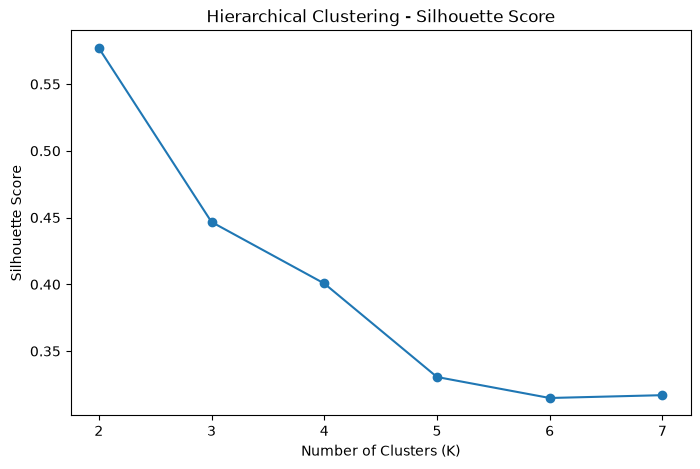

In [30]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 8),
    results,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Hierarchical Clustering - Silhouette Score")

plt.xticks(range(2, 8))

plt.show()

In [31]:
model = AgglomerativeClustering(
    n_clusters=2,
    linkage="ward"
)

labels_hc_2 = model.fit_predict(X_scaled)

df["HC_K2"] = labels_hc_2

print("Cluster Sizes:")
print(
    df["HC_K2"]
    .value_counts()
    .sort_index()
)

print("\nSilhouette Score:")

print(
    silhouette_score(
        X_scaled,
        labels_hc_2
    )
)

Cluster Sizes:
HC_K2
0    101
1     49
Name: count, dtype: int64

Silhouette Score:
0.5770346019475988


In [ ]:
pd.crosstab(
    df["target"],
    df["HC_K2"]
)